In [1]:
# 웹 스크래핑 가능 유무 확인을 위한 모듈 탑재
import requests

# 웹 스트래핑 대상 주소 저장
url = 'https://finance.naver.com/item/sise_day.naver?code=005930&page=2'

# http 요정을 대상 주소로 보내고 , HTTP 응답 받아서 저장하기 
page = requests.get(url)

# 응답 내용 확인하기
print(page.text)


<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN" "http://www.w3.org/TR/html4/loose.dtd">
<html>
<head>
<meta http-equiv="Content-Type" content="text/html; charset=euc-kr">
<title>네이버 :: 세상의 모든 지식, 네이버</title>

<style type="text/css">
.error_content * {margin:0;padding:0;}
.error_content img{border:none;}
.error_content em {font-style:normal;}
.error_content {width:410px; margin:80px auto 0; padding:57px 0 0 0; font-size:12px; font-family:"나눔고딕", "NanumGothic", "돋움", Dotum, AppleGothic, Sans-serif; text-align:left; line-height:14px; background:url(https://ssl.pstatic.net/static/common/error/090610/bg_thumb.gif) no-repeat center top; white-space:nowrap;}
.error_content p{margin:0;}
.error_content .error_desc {margin-bottom:21px; overflow:hidden; text-align:center;}
.error_content .error_desc2 {margin-bottom:11px; padding-bottom:7px; color:#888; line-height:18px; border-bottom:1px solid #eee;}
.error_content .error_desc3 {clear:both; color:#888;}
.error_content .error_desc3

## 요청 헤더에 값 설정 후 웹 정보 확인하기

In [2]:
# 헤더 정보 설정하기
my_headers = {'user-agent':'Mozilla/5.0'}

# 요청 헤더 설정하여 HTTP 응답 받아오기
page = requests.get(url, headers=my_headers)

# 응답 내용 확인하기
print(page.text)


<html lang="ko">
<head>
<meta http-equiv="Content-Type" content="text/html; charset=euc-kr">
<title>Npay 증권</title>

<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/newstock.css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/common.css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/finance_header.css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/layout.css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/main.css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/newstock2.css">
<link rel="stylesheet" type="text/css" href="https://ssl.pstatic.net/imgstock/static.pc/20260504141942/css/newstock3.css">
<link rel="stylesheet" type=

In [3]:
# 판다스 라이브러리 탑재
import pandas as pd
from io import StringIO

# HTML 페이지에서 테이블 추출
pages = pd.read_html(StringIO(page.text))

# 추출한 데이터 타입 확인하기
type(pages)

list

## 필요한 테이블 데이터 고르기

In [4]:
# 페이지 개수 확인하기
len(pages)


2

In [5]:
# 첫 번째 테이블 내용 확인하기
pages[0]

,날짜,종가,전일비,시가,고가,저가,거래량
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026.04.27,224500.0,"상승 5,000",220000.0,226000.0,218500.0,22870374.0
2,2026.04.24,219500.0,"하락 5,000",224000.0,225000.0,216500.0,19626666.0
3,2026.04.23,224500.0,"상승 7,000",223000.0,229500.0,216000.0,34525485.0
4,2026.04.22,217500.0,"하락 1,500",218500.0,222500.0,215500.0,16823480.0
5,2026.04.21,219000.0,"상승 4,500",218000.0,220000.0,216000.0,16752132.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026.04.20,214500.0,"하락 1,500",214500.0,219000.0,213000.0,17107741.0


In [6]:
# 두 번째 데이블 내용 확인하기
pages[1]

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,맨앞,1,2,3,4,5,6,7,8,9,10,다음,맨뒤


## 페이지 번호 증가용 반복문 작성

In [9]:
import pandas as pd
import io

# 페이지 번호를 제외한 주소 저장
new_url = 'https://finance.naver.com/item/sise_day.naver?code=005930&page='

# 데이터를 축적할 데이터 프레임 생성
all_tables = pd.DataFrame()
    
# 페이지 번호 증가용 반복문
for page_number in range(1,2):

    # 페이지 번호 추가한 주소 완성
    full_url = new_url + str(page_number)

    # 주소 확인하기
    print(f'{page_number} 번째 페이지 읽어오기({full_url})')

    # HTTP 요청 전송 후 응답 받아오기
    page = requests.get(full_url, headers=my_headers)

    #데이블 추출
    table = pd.read_html(io.StringIO(page.text))[0]

    # 수행할 내용 확인
    print(f'전체 {len(all_tables.index)} 중레 {len(table.index)} 줄 추가')

    # 데이터 축적용 데이터프레임에 테이블 추가
    all_tables = pd.concat([all_tables, table])

1 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=005930&page=1)
전체 0 중레 15 줄 추가


In [10]:
# 전체 테이블 결과 확인
all_tables

,날짜,종가,전일비,시가,고가,저가,거래량
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026.05.13,284500.0,"상승 5,500",264000.0,285500.0,262000.0,33368989.0
2,2026.05.12,279000.0,"하락 6,500",290000.0,291500.0,266000.0,41211149.0
3,2026.05.11,285500.0,"상승 17,000",284500.0,288500.0,280000.0,36031094.0
4,2026.05.08,268500.0,"하락 3,000",260000.0,270000.0,260000.0,25875880.0
5,2026.05.07,271500.0,"상승 5,500",272000.0,277000.0,260000.0,41404687.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026.05.06,266000.0,"상승 33,500",254000.0,270000.0,251000.0,53097996.0


In [11]:
# 결손치 제거
all_tables.dropna(inplace=True)

# 데이터 확인하기
all_tables

,날짜,종가,전일비,시가,고가,저가,거래량
1,2026.05.13,284500.0,"상승 5,500",264000.0,285500.0,262000.0,33368989.0
2,2026.05.12,279000.0,"하락 6,500",290000.0,291500.0,266000.0,41211149.0
3,2026.05.11,285500.0,"상승 17,000",284500.0,288500.0,280000.0,36031094.0
4,2026.05.08,268500.0,"하락 3,000",260000.0,270000.0,260000.0,25875880.0
5,2026.05.07,271500.0,"상승 5,500",272000.0,277000.0,260000.0,41404687.0
9,2026.05.06,266000.0,"상승 33,500",254000.0,270000.0,251000.0,53097996.0
10,2026.05.04,232500.0,"상승 12,000",228000.0,232500.0,224000.0,32920816.0
11,2026.04.30,220500.0,"하락 5,500",229000.0,230000.0,220500.0,22161975.0
12,2026.04.29,226000.0,"상승 4,000",219500.0,228000.0,218500.0,20363756.0
13,2026.04.28,222000.0,"하락 2,500",224000.0,226000.0,221500.0,18444490.0


In [38]:
# 데이터를 축적할 데이터 프레임 생성
all_tables = pd.DataFrame()

# 페이지 번호 증가용 반복문 
for page_number in range(1,11):

    # 페이지 번호 추가한 주소 완성
    full_url = new_url + str(page_number)

    # 주소 확인하기
    print(f'{page_number} 번째 페이지 읽어보기({full_url})')

    # HTTP 요청 전송 후 응답 받아오기
    page = requests.get(full_url, headers=my_headers)

    # 테이블 추출
    table = pd.read_html(io.StringIO(page.text))[0]

    # 수행할 내용 확인
    print(f'전체 {len(all_tables.index)} 줄에 {len(table.index)} 줄 추가')

    # 데이터 축적용 데이터프레임 태이블 추가
    all_tables = pd.concat([all_tables, table])

1 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=1)
전체 0 줄에 15 줄 추가
2 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=2)
전체 15 줄에 15 줄 추가
3 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=3)
전체 30 줄에 15 줄 추가
4 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=4)
전체 45 줄에 15 줄 추가
5 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=5)
전체 60 줄에 15 줄 추가
6 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=6)
전체 75 줄에 15 줄 추가
7 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=7)
전체 90 줄에 15 줄 추가
8 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=8)
전체 105 줄에 15 줄 추가
9 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=9)
전체 120 줄에 15 줄 추가
10 번째 페이지 읽어보기(https://finance.naver.com/item/sise_day.naver?code=005930&page=10)
전체 135 줄에 15 줄 추가


In [39]:
# 결손치 제거
all_tables.dropna(inplace=True)

# 데이터 확인하기
all_tables

,날짜,종가,전일비,시가,고가,저가,거래량
1,2026.05.13,284500.0,"상승 5,500",264000.0,285500.0,262000.0,33368989.0
2,2026.05.12,279000.0,"하락 6,500",290000.0,291500.0,266000.0,41211149.0
3,2026.05.11,285500.0,"상승 17,000",284500.0,288500.0,280000.0,36031094.0
4,2026.05.08,268500.0,"하락 3,000",260000.0,270000.0,260000.0,25875880.0
5,2026.05.07,271500.0,"상승 5,500",272000.0,277000.0,260000.0,41404687.0
...,...,...,...,...,...,...,...
9,2025.12.18,107600.0,하락 300,106400.0,108200.0,105700.0,20445631.0
10,2025.12.17,107900.0,"상승 5,100",103500.0,108100.0,103400.0,22297611.0
11,2025.12.16,102800.0,"하락 2,000",104900.0,105600.0,102700.0,18852079.0
12,2025.12.15,104800.0,"하락 4,100",105300.0,105800.0,104600.0,20594654.0


## 한글 열 이름을 영문으로 변경하기

In [40]:
#열 이름 영문으로 변경
all_tables.rename(columns={'날짜' : 'date',
                           '종가' : 'end_price',
                           '시가' : 'start_price',
                           '고가': 'highest_price',
                           '저가' : 'lowest_price'}
                  , inplace = True)
#데이터 확인하기
all_tables

,date,end_price,전일비,start_price,highest_price,lowest_price,거래량
1,2026.05.13,284500.0,"상승 5,500",264000.0,285500.0,262000.0,33368989.0
2,2026.05.12,279000.0,"하락 6,500",290000.0,291500.0,266000.0,41211149.0
3,2026.05.11,285500.0,"상승 17,000",284500.0,288500.0,280000.0,36031094.0
4,2026.05.08,268500.0,"하락 3,000",260000.0,270000.0,260000.0,25875880.0
5,2026.05.07,271500.0,"상승 5,500",272000.0,277000.0,260000.0,41404687.0
...,...,...,...,...,...,...,...
9,2025.12.18,107600.0,하락 300,106400.0,108200.0,105700.0,20445631.0
10,2025.12.17,107900.0,"상승 5,100",103500.0,108100.0,103400.0,22297611.0
11,2025.12.16,102800.0,"하락 2,000",104900.0,105600.0,102700.0,18852079.0
12,2025.12.15,104800.0,"하락 4,100",105300.0,105800.0,104600.0,20594654.0


In [41]:
#필요없는 열 제거
all_tables.drop(['전일비','거래량'], axis=1, inplace=True)

#데이터 확인하기
all_tables

,date,end_price,start_price,highest_price,lowest_price
1,2026.05.13,284500.0,264000.0,285500.0,262000.0
2,2026.05.12,279000.0,290000.0,291500.0,266000.0
3,2026.05.11,285500.0,284500.0,288500.0,280000.0
4,2026.05.08,268500.0,260000.0,270000.0,260000.0
5,2026.05.07,271500.0,272000.0,277000.0,260000.0
...,...,...,...,...,...
9,2025.12.18,107600.0,106400.0,108200.0,105700.0
10,2025.12.17,107900.0,103500.0,108100.0,103400.0
11,2025.12.16,102800.0,104900.0,105600.0,102700.0
12,2025.12.15,104800.0,105300.0,105800.0,104600.0


In [42]:
#중앙값 열 추가
all_tables['midian_price'] = all_tables['highest_price'] - ((all_tables
                                                             ['highest_price'] - all_tables['lowest_price']) /2)
#값 확인하기
all_tables

,date,end_price,start_price,highest_price,lowest_price,midian_price
1,2026.05.13,284500.0,264000.0,285500.0,262000.0,273750.0
2,2026.05.12,279000.0,290000.0,291500.0,266000.0,278750.0
3,2026.05.11,285500.0,284500.0,288500.0,280000.0,284250.0
4,2026.05.08,268500.0,260000.0,270000.0,260000.0,265000.0
5,2026.05.07,271500.0,272000.0,277000.0,260000.0,268500.0
...,...,...,...,...,...,...
9,2025.12.18,107600.0,106400.0,108200.0,105700.0,106950.0
10,2025.12.17,107900.0,103500.0,108100.0,103400.0,105750.0
11,2025.12.16,102800.0,104900.0,105600.0,102700.0,104150.0
12,2025.12.15,104800.0,105300.0,105800.0,104600.0,105200.0


## 집계를 위한 달 정보 추가하기

In [43]:
# 월 정보 열 추가
all_tables['month'] = all_tables['date'].str[0:7]

# 확인
all_tables

,date,end_price,start_price,highest_price,lowest_price,midian_price,month
1,2026.05.13,284500.0,264000.0,285500.0,262000.0,273750.0,2026.05
2,2026.05.12,279000.0,290000.0,291500.0,266000.0,278750.0,2026.05
3,2026.05.11,285500.0,284500.0,288500.0,280000.0,284250.0,2026.05
4,2026.05.08,268500.0,260000.0,270000.0,260000.0,265000.0,2026.05
5,2026.05.07,271500.0,272000.0,277000.0,260000.0,268500.0,2026.05
...,...,...,...,...,...,...,...
9,2025.12.18,107600.0,106400.0,108200.0,105700.0,106950.0,2025.12
10,2025.12.17,107900.0,103500.0,108100.0,103400.0,105750.0,2025.12
11,2025.12.16,102800.0,104900.0,105600.0,102700.0,104150.0,2025.12
12,2025.12.15,104800.0,105300.0,105800.0,104600.0,105200.0,2025.12


## 색인 변경 및 정렬하기

In [44]:
#날짜 색인으로 지정
all_tables.set_index('date', inplace = True)

#날짜 오름차순으로 정렬
all_tables.sort_index(inplace=True)

#값 확인하기
all_tables

,end_price,start_price,highest_price,lowest_price,midian_price,month
date,,,,,,
2025.12.12,108900.0,107100.0,108900.0,106800.0,107850.0,2025.12
2025.12.15,104800.0,105300.0,105800.0,104600.0,105200.0,2025.12
2025.12.16,102800.0,104900.0,105600.0,102700.0,104150.0,2025.12
2025.12.17,107900.0,103500.0,108100.0,103400.0,105750.0,2025.12
2025.12.18,107600.0,106400.0,108200.0,105700.0,106950.0,2025.12
...,...,...,...,...,...,...
2026.05.07,271500.0,272000.0,277000.0,260000.0,268500.0,2026.05
2026.05.08,268500.0,260000.0,270000.0,260000.0,265000.0,2026.05
2026.05.11,285500.0,284500.0,288500.0,280000.0,284250.0,2026.05


<Axes: xlabel='date'>

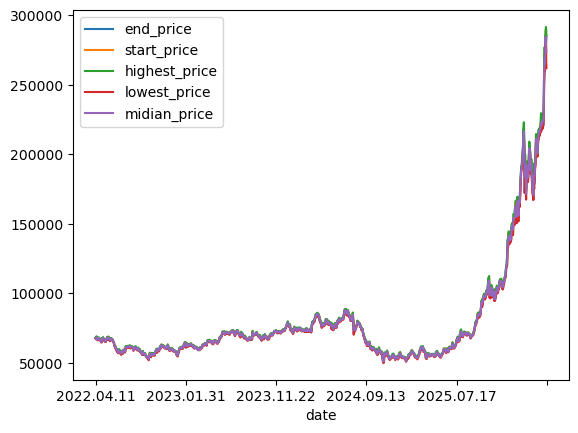

In [32]:
# 전체 숫자 데이터 선 그래프로 그리기
all_tables.plot.line()

<Axes: xlabel='date'>

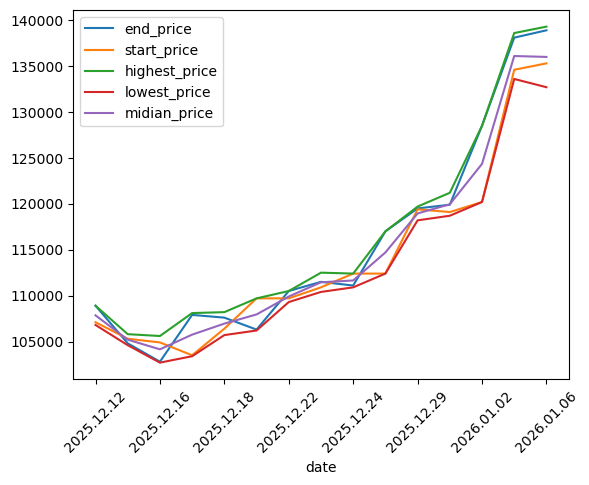

In [45]:
# 앞 15일치 데이터 선 그래프로 그리기
all_tables[:15].plot.line(rot=45)

<Axes: title={'center': 'midian_price'}, xlabel='[month]'>

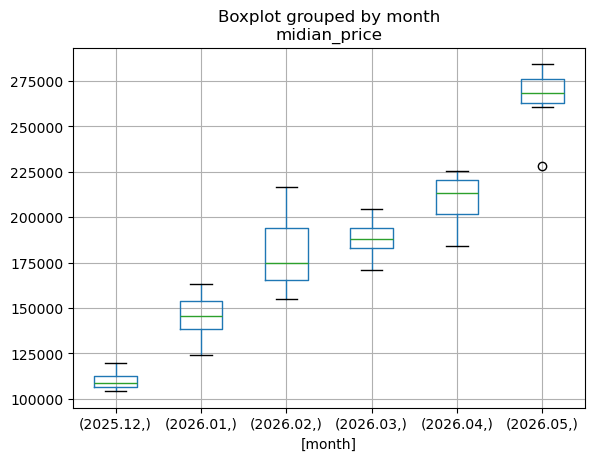

In [47]:
# 일일 시세 중앙값의 상자 수염 그래프 그리기
all_tables.boxplot(column=['midian_price'], by=['month'])

<Axes: title={'center': 'midian_price'}, xlabel='[month]'>

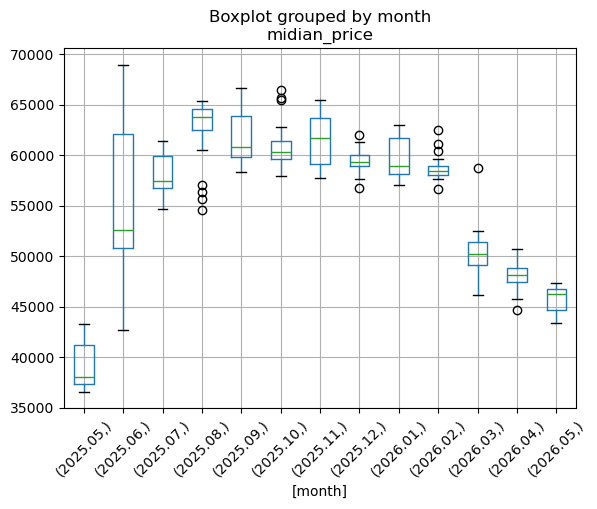

In [54]:
# 페이지 번호를 제외한 주소 저장
kakao_url = 'https://finance.naver.com/item/sise_day.naver?code=035720&page='
my_headers = {'user-agent':'Mozilla/5.0'}
all_tables = pd.DataFrame()

# 페이지 번호 증가용 반복문 
for page_number in range(1,25):
    full_url = kakao_url + str(page_number)
    page = requests.get(full_url, headers=my_headers)
    table = pd.read_html(io.StringIO(page.text))[0]
    all_tables = pd.concat([all_tables, table])


all_tables.rename(columns={'날짜' : 'date',
                           '종가' : 'end_price',
                           '시가' : 'start_price',
                           '고가': 'highest_price',
                           '저가' : 'lowest_price'}
                  , inplace = True)
all_tables['month'] = all_tables['date'].str[0:7]
all_tables.drop(['전일비','거래량'], axis=1, inplace=True)
all_tables['midian_price'] = all_tables['highest_price'] - ((all_tables
                                                             ['highest_price'] - all_tables['lowest_price']) /2)


all_tables.set_index('date', inplace = True)
all_tables.sort_index(inplace=True)
all_tables.boxplot(column=['midian_price'], by=['month'], rot=45)
